# Bayesian Customer Lifetime Value Modelling

This notebook implements a model-based machine learning project for customer lifetime value (CLV) modelling using transaction-level online retail data.

The goal is to build probabilistic generative models that describe customer purchasing behaviour. Instead of only predicting future revenue with a deterministic model, we model uncertainty in customer-level purchase frequency and monetary value.

We implement three models:

1. A Gamma--Poisson purchase-count model.
2. A hierarchical country-level purchase-count model.
3. A joint frequency and monetary-value model.

The final model can be used to estimate a posterior predictive distribution over future customer value.

## 1. Install and import packages

The required packages are imported below. The implementation uses Pyro for probabilistic modelling and stochastic variational inference, PyTorch for tensor operations, pandas for data handling, and matplotlib for diagnostic plots.

In [25]:
# If needed:
# !pip install pyro-ppl pandas numpy scikit-learn matplotlib openpyxl

import numpy as np
import pandas as pd
import torch
import pyro
import pyro.distributions as dist

from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoNormal
from pyro.optim import Adam

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

pyro.set_rng_seed(42)
torch.manual_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

## 2. Load and clean the Online Retail data

The raw dataset is transaction-level retail data. Each row corresponds to a purchased item on an invoice.

The relevant columns are:

\[
\texttt{InvoiceNo},\quad
\texttt{Quantity},\quad
\texttt{InvoiceDate},\quad
\texttt{UnitPrice},\quad
\texttt{CustomerID},\quad
\texttt{Country}.
\]

The cleaning procedure removes rows with missing customer IDs, cancelled invoices, negative quantities, and non-positive unit prices. Revenue is computed at the line-item level as

\[
\text{Revenue}_{ij} = \text{Quantity}_{ij} \cdot \text{UnitPrice}_{ij}.
\]

Here, \(i\) indexes the invoice and \(j\) indexes the product line within that invoice.

In [26]:
# Change this path to match your downloaded Kaggle file.
# Common filenames are "Online Retail.xlsx", "OnlineRetail.csv", or similar.

path = "online_retail.csv"

if path.endswith(".xlsx"):
    raw = pd.read_excel(path)
else:
    raw = pd.read_csv(path, encoding="latin1")

raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [27]:
df = raw.copy()

# Standardize column names defensively.
df.columns = [c.strip() for c in df.columns]

required_cols = [
    "InvoiceNo", "Quantity", "InvoiceDate",
    "UnitPrice", "CustomerID", "Country"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

# Remove rows without customer ID.
df = df.dropna(subset=["CustomerID"]).copy()

# Remove cancellations and returns.
# In this dataset, cancelled invoices often start with "C"; negative quantities also represent returns/cancellations.
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df = df[~df["InvoiceNo"].str.startswith("C")].copy()
df = df[df["Quantity"] > 0].copy()
df = df[df["UnitPrice"] > 0].copy()

# Dates and line-item revenue.
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["CustomerID"] = df["CustomerID"].astype(int).astype(str)
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.shape, df.head()

((397884, 9),
   InvoiceNo StockCode                          Description  Quantity  \
 0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
 1    536365     71053                  WHITE METAL LANTERN         6   
 2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
 3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
 4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
 
           InvoiceDate  UnitPrice CustomerID         Country  Revenue  
 0 2010-12-01 08:26:00       2.55      17850  United Kingdom    15.30  
 1 2010-12-01 08:26:00       3.39      17850  United Kingdom    20.34  
 2 2010-12-01 08:26:00       2.75      17850  United Kingdom    22.00  
 3 2010-12-01 08:26:00       3.39      17850  United Kingdom    20.34  
 4 2010-12-01 08:26:00       3.39      17850  United Kingdom    20.34  )

In [28]:
invoice_df = (
    df.groupby(["CustomerID", "InvoiceNo"], as_index=False)
      .agg(
          InvoiceDate=("InvoiceDate", "min"),
          Country=("Country", "first"),
          Revenue=("Revenue", "sum"),
          NumItems=("Quantity", "sum"),
          NumUniqueProducts=("StockCode", "nunique") if "StockCode" in df.columns else ("InvoiceNo", "size")
      )
)

invoice_df = invoice_df[invoice_df["Revenue"] > 0].copy()
invoice_df.head()

,CustomerID,InvoiceNo,InvoiceDate,Country,Revenue,NumItems,NumUniqueProducts
0,12346,541431,2011-01-18 10:01:00,United Kingdom,77183.60,74215,1
1,12347,537626,2010-12-07 14:57:00,Iceland,711.79,319,31
2,12347,542237,2011-01-26 14:30:00,Iceland,475.39,315,29
3,12347,549222,2011-04-07 10:43:00,Iceland,636.25,483,24
4,12347,556201,2011-06-09 13:01:00,Iceland,382.52,196,18


In [29]:
study_end = invoice_df["InvoiceDate"].max()

customer_df = (
    invoice_df.groupby("CustomerID", as_index=False)
      .agg(
          first_purchase=("InvoiceDate", "min"),
          last_purchase=("InvoiceDate", "max"),
          n_purchases=("InvoiceNo", "nunique"),
          total_revenue=("Revenue", "sum"),
          mean_revenue=("Revenue", "mean"),
          median_revenue=("Revenue", "median"),
          mean_items=("NumItems", "mean"),
          product_diversity=("NumUniqueProducts", "mean"),
          Country=("Country", "first")
      )
)

customer_df["customer_age_days"] = (
    study_end - customer_df["first_purchase"]
).dt.days.clip(lower=1)

customer_df["recency_days"] = (
    study_end - customer_df["last_purchase"]
).dt.days.clip(lower=0)

customer_df["log_exposure"] = np.log(customer_df["customer_age_days"] / 365.25)

# Optional: avoid extreme whales dominating a student project.
# You can comment this out if you want to model all customers.
upper = customer_df["total_revenue"].quantile(0.995)
customer_df = customer_df[customer_df["total_revenue"] <= upper].copy()

customer_df.describe()

,first_purchase,last_purchase,n_purchases,total_revenue,mean_revenue,median_revenue,mean_items,product_diversity,customer_age_days,recency_days,log_exposure
count,4316,4316,4316.000000,4316.000000,4316.000000,4316.000000,4316.000000,4316.000000,4316.000000,4316.000000,4316.000000
mean,2011-05-01 07:35:10.579240,2011-09-08 04:18:54.175162,4.055144,1552.078972,369.651120,353.992189,221.123451,21.475289,221.705514,91.841752,-0.774313
min,2010-12-01 08:26:00,2010-12-01 09:53:00,1.000000,3.750000,3.450000,3.450000,1.000000,1.000000,1.000000,0.000000,-5.900582
25%,2011-01-17 15:17:00,2011-07-20 11:03:00,1.000000,306.720000,178.300000,168.842500,92.950000,9.444643,111.000000,17.000000,-1.191052
50%,2011-04-05 15:20:30,2011-10-19 15:21:00,2.000000,668.250000,292.032500,288.325000,161.000000,16.851648,247.000000,50.000000,-0.391194
75%,2011-08-19 13:49:30,2011-11-22 09:23:30,5.000000,1634.250000,426.651705,409.026250,269.352273,27.571429,325.000000,142.000000,-0.116757
max,2011-12-09 12:16:00,2011-12-09 12:50:00,209.000000,40991.570000,13305.500000,6207.670000,7824.000000,219.000000,373.000000,373.000000,0.020996
std,NaN,NaN,6.400117,2917.285673,414.111203,360.272996,270.057528,18.625155,117.794112,100.013713,0.928004


In [30]:
# Keep countries with enough customers; group the rest as "Other".
min_country_count = 30
country_counts = customer_df["Country"].value_counts()
major_countries = country_counts[country_counts >= min_country_count].index

customer_df["CountryGroup"] = np.where(
    customer_df["Country"].isin(major_countries),
    customer_df["Country"],
    "Other"
)

country_codes, country_uniques = pd.factorize(customer_df["CountryGroup"])
customer_df["country_idx"] = country_codes

# Continuous covariates for customer-level predictors.
feature_cols = [
    "recency_days",
    "mean_items",
    "product_diversity"
]

scaler = StandardScaler()
X = scaler.fit_transform(customer_df[feature_cols])

# Tensors.
n_purchases = torch.tensor(customer_df["n_purchases"].values, dtype=torch.float32, device=DEVICE)
exposure = torch.tensor(customer_df["customer_age_days"].values / 365.25, dtype=torch.float32, device=DEVICE)
log_exposure = torch.log(exposure)

X_tensor = torch.tensor(X, dtype=torch.float32, device=DEVICE)

country_idx = torch.tensor(customer_df["country_idx"].values, dtype=torch.long, device=DEVICE)

N = len(customer_df)
P = X_tensor.shape[1]
C = customer_df["country_idx"].nunique()

N, P, C

(4316, 3, 4)

model 1

In [31]:
def model_1_gamma_poisson(n_purchases, exposure):
    """
    Simple customer-level Gamma-Poisson model.

    n_purchases: tensor of shape [N]
    exposure: tensor of shape [N], observed customer lifetime in years
    """
    N = n_purchases.shape[0]

    alpha = pyro.sample("alpha", dist.LogNormal(0.0, 1.0))
    beta = pyro.sample("beta", dist.LogNormal(0.0, 1.0))

    with pyro.plate("customers", N):
        lambda_i = pyro.sample("lambda_i", dist.Gamma(alpha, beta))
        pyro.sample(
            "obs",
            dist.Poisson(lambda_i * exposure),
            obs=n_purchases
        )

In [32]:
def train_svi(model, model_args, num_steps=3000, lr=0.02):
    pyro.clear_param_store()

    guide = AutoNormal(model)
    optimizer = Adam({"lr": lr})
    svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

    losses = []
    for step in range(num_steps):
        loss = svi.step(*model_args)
        losses.append(loss)

        if step % 500 == 0:
            print(f"step {step:04d} | loss = {loss:.2f}")

    return guide, losses

step 0000 | loss = 40274.63
step 0500 | loss = 10458.45
step 1000 | loss = 10465.40
step 1500 | loss = 10461.63
step 2000 | loss = 10472.22
step 2500 | loss = 10463.72


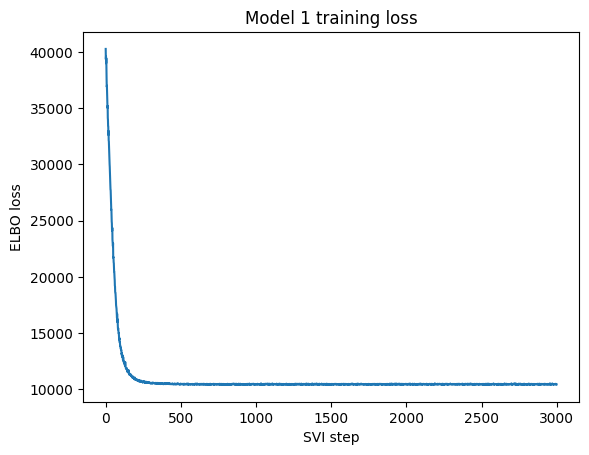

In [33]:
guide_1, losses_1 = train_svi(
    model_1_gamma_poisson,
    (n_purchases, exposure),
    num_steps=3000,
    lr=0.02
)

plt.figure()
plt.plot(losses_1)
plt.xlabel("SVI step")
plt.ylabel("ELBO loss")
plt.title("Model 1 training loss")
plt.show()

In [34]:
predictive_1 = Predictive(
    model_1_gamma_poisson,
    guide=guide_1,
    num_samples=1000,
    return_sites=["alpha", "beta", "lambda_i", "obs"]
)

posterior_1 = predictive_1(n_purchases, exposure)

for k, v in posterior_1.items():
    print(k, v.shape)

alpha torch.Size([1000, 1])
beta torch.Size([1000, 1])
lambda_i torch.Size([1000, 4316])
obs torch.Size([1000, 4316])


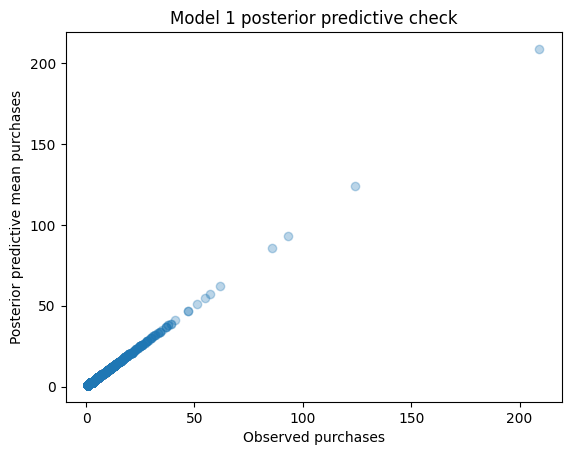

In [35]:
# Posterior predictive check: compare observed and simulated purchase counts.
obs_sim_1 = posterior_1["obs"].detach().cpu().numpy()

sim_mean_counts = obs_sim_1.mean(axis=0)

plt.figure()
plt.scatter(customer_df["n_purchases"], sim_mean_counts, alpha=0.3)
plt.xlabel("Observed purchases")
plt.ylabel("Posterior predictive mean purchases")
plt.title("Model 1 posterior predictive check")
plt.show()

modl 2

In [39]:
def model_2_hierarchical_country(n_purchases, exposure, X, country_idx, num_countries):
    """
    Hierarchical Poisson regression for purchase counts.

    n_purchases: [N]
    exposure: [N]
    X: [N, P]
    country_idx: [N]
    num_countries: int
    """
    N, P = X.shape

    alpha = pyro.sample("alpha", dist.Normal(0.0, 2.0))

    beta = pyro.sample(
        "beta",
        dist.Normal(
            torch.zeros(P, device=X.device),
            torch.ones(P, device=X.device)
        ).to_event(1)
    )

    sigma_country = pyro.sample("sigma_country", dist.HalfNormal(1.0))

    with pyro.plate("countries", num_countries):
        country_effect = pyro.sample(
            "country_effect",
            dist.Normal(0.0, sigma_country)
        )

    # Shape fixes for posterior predictive sampling.
    alpha = alpha.squeeze()
    beta = beta.reshape(P)
    country_effect = country_effect.reshape(num_countries)

    log_rate = alpha + torch.matmul(X, beta) + country_effect[country_idx]
    rate = torch.exp(log_rate)

    with pyro.plate("customers", N):
        pyro.sample(
            "obs",
            dist.Poisson(rate * exposure),
            obs=n_purchases
        )

step 0000 | loss = 32078.31
step 0500 | loss = 10334.66
step 1000 | loss = 10329.79
step 1500 | loss = 10328.40
step 2000 | loss = 10330.76
step 2500 | loss = 10330.34
step 3000 | loss = 10331.35
step 3500 | loss = 10328.52


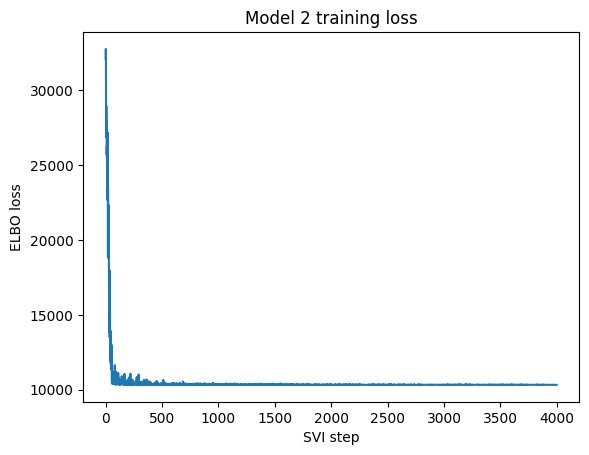

In [40]:
guide_2, losses_2 = train_svi(
    model_2_hierarchical_country,
    (n_purchases, exposure, X_tensor, country_idx, C),
    num_steps=4000,
    lr=0.015
)

plt.figure()
plt.plot(losses_2)
plt.xlabel("SVI step")
plt.ylabel("ELBO loss")
plt.title("Model 2 training loss")
plt.show()

In [43]:
predictive_2 = Predictive(
    model_2_hierarchical_country,
    guide=guide_2,
    num_samples=1000,
    return_sites=["alpha", "beta", "sigma_country", "country_effect", "obs"]
)

posterior_2 = predictive_2(n_purchases, exposure, X_tensor, country_idx, C)

for k, v in posterior_2.items():
    print(k, v.shape)

alpha torch.Size([1000, 1])
beta torch.Size([1000, 1, 3])
sigma_country torch.Size([1000, 1])
country_effect torch.Size([1000, 4])
obs torch.Size([1000, 4316])


In [45]:
beta_samples = posterior_2["beta"].detach().cpu().numpy()

print("Original beta_samples shape:", beta_samples.shape)

# Remove singleton dimensions safely.
beta_samples = np.squeeze(beta_samples)

print("Squeezed beta_samples shape:", beta_samples.shape)

# Ensure final shape is [num_samples, num_features].
if beta_samples.ndim == 1:
    beta_samples = beta_samples.reshape(-1, len(feature_cols))

elif beta_samples.shape[-1] == len(feature_cols):
    beta_samples = beta_samples.reshape(-1, len(feature_cols))

else:
    raise ValueError(
        f"Unexpected beta_samples shape after squeeze: {beta_samples.shape}. "
        f"Expected last dimension to equal number of features: {len(feature_cols)}."
    )

summary_rows = []
for j, name in enumerate(feature_cols):
    samples = beta_samples[:, j]
    summary_rows.append({
        "feature": name,
        "posterior_mean": samples.mean(),
        "q05": np.quantile(samples, 0.05),
        "q50": np.quantile(samples, 0.50),
        "q95": np.quantile(samples, 0.95),
    })

beta_summary = pd.DataFrame(summary_rows)
beta_summary

Original beta_samples shape: (1000, 1, 3)
Squeezed beta_samples shape: (1000, 3)


,feature,posterior_mean,q05,q50,q95
0,recency_days,-0.784600,-0.802324,-0.784035,-0.768497
1,mean_items,0.026068,0.013687,0.025856,0.040424
2,product_diversity,-0.070504,-0.085189,-0.070410,-0.055716


In [46]:
country_effect_samples = posterior_2["country_effect"].detach().cpu().numpy()

print("Original country_effect_samples shape:", country_effect_samples.shape)

country_effect_samples = np.squeeze(country_effect_samples)

print("Squeezed country_effect_samples shape:", country_effect_samples.shape)

if country_effect_samples.ndim == 1:
    country_effect_samples = country_effect_samples.reshape(-1, C)

elif country_effect_samples.shape[-1] == C:
    country_effect_samples = country_effect_samples.reshape(-1, C)

else:
    raise ValueError(
        f"Unexpected country_effect_samples shape after squeeze: {country_effect_samples.shape}. "
        f"Expected last dimension to equal number of countries: {C}."
    )

country_summary = []
for c, country in enumerate(country_uniques):
    s = country_effect_samples[:, c]
    country_summary.append({
        "country": country,
        "posterior_mean_log_effect": s.mean(),
        "q05": np.quantile(s, 0.05),
        "q50": np.quantile(s, 0.50),
        "q95": np.quantile(s, 0.95),
    })

country_summary = pd.DataFrame(country_summary).sort_values(
    "posterior_mean_log_effect",
    ascending=False
)

country_summary.head(10)

Original country_effect_samples shape: (1000, 4)
Squeezed country_effect_samples shape: (1000, 4)


,country,posterior_mean_log_effect,q05,q50,q95
2,Germany,0.819120,0.744647,0.819278,0.894408
1,France,0.787017,0.710836,0.785887,0.867155
3,United Kingdom,0.762381,0.747264,0.762417,0.776785
0,Other,0.567478,0.509357,0.566924,0.629356


mdl 3

In [47]:
mean_revenue = torch.tensor(
    customer_df["mean_revenue"].values,
    dtype=torch.float32,
    device=DEVICE
)

log_mean_revenue = torch.log(mean_revenue)

In [48]:
def model_3_joint_frequency_monetary(
    n_purchases,
    exposure,
    log_mean_revenue,
    X,
    country_idx,
    num_countries
):
    """
    Joint model:
    - Poisson purchase frequency
    - LogNormal-like average monetary value via Normal likelihood on log mean revenue
    """
    N, P = X.shape

    # Frequency component.
    alpha_lambda = pyro.sample("alpha_lambda", dist.Normal(0.0, 2.0))
    beta_lambda = pyro.sample(
        "beta_lambda",
        dist.Normal(torch.zeros(P, device=DEVICE), torch.ones(P, device=DEVICE)).to_event(1)
    )

    # Monetary component.
    alpha_money = pyro.sample("alpha_money", dist.Normal(log_mean_revenue.mean(), 2.0))
    beta_money = pyro.sample(
        "beta_money",
        dist.Normal(torch.zeros(P, device=DEVICE), torch.ones(P, device=DEVICE)).to_event(1)
    )

    sigma_country_lambda = pyro.sample("sigma_country_lambda", dist.HalfNormal(1.0))
    sigma_country_money = pyro.sample("sigma_country_money", dist.HalfNormal(1.0))
    sigma_money = pyro.sample("sigma_money", dist.HalfNormal(1.0))

    with pyro.plate("countries", num_countries):
        country_lambda = pyro.sample(
            "country_lambda",
            dist.Normal(0.0, sigma_country_lambda)
        )

        country_money = pyro.sample(
            "country_money",
            dist.Normal(0.0, sigma_country_money)
        )

    log_rate = alpha_lambda + X @ beta_lambda + country_lambda[country_idx]
    rate = torch.exp(log_rate)

    money_mean = alpha_money + X @ beta_money + country_money[country_idx]

    with pyro.plate("customers", N):
        pyro.sample(
            "purchase_count_obs",
            dist.Poisson(rate * exposure),
            obs=n_purchases
        )

        pyro.sample(
            "log_mean_revenue_obs",
            dist.Normal(money_mean, sigma_money),
            obs=log_mean_revenue
        )

step 0000 | loss = 93770.06
step 0500 | loss = 19668.98
step 1000 | loss = 15786.80
step 1500 | loss = 13875.50
step 2000 | loss = 13811.22
step 2500 | loss = 13823.60
step 3000 | loss = 13808.76
step 3500 | loss = 13831.36
step 4000 | loss = 13822.09
step 4500 | loss = 13810.98


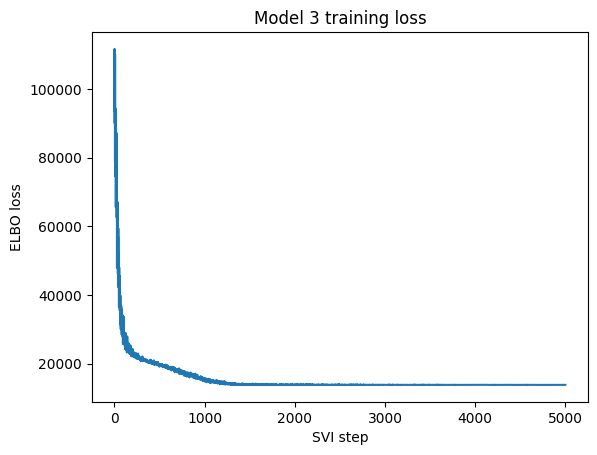

In [49]:
guide_3, losses_3 = train_svi(
    model_3_joint_frequency_monetary,
    (n_purchases, exposure, log_mean_revenue, X_tensor, country_idx, C),
    num_steps=5000,
    lr=0.01
)

plt.figure()
plt.plot(losses_3)
plt.xlabel("SVI step")
plt.ylabel("ELBO loss")
plt.title("Model 3 training loss")
plt.show()

In [53]:
def model_3_joint_frequency_monetary(
    n_purchases,
    exposure,
    log_mean_revenue,
    X,
    country_idx,
    num_countries
):
    """
    Joint model:
    - Poisson purchase frequency
    - LogNormal-like average monetary value via Normal likelihood on log mean revenue
    """
    N, P = X.shape

    # Frequency component.
    alpha_lambda = pyro.sample("alpha_lambda", dist.Normal(0.0, 2.0))

    beta_lambda = pyro.sample(
        "beta_lambda",
        dist.Normal(
            torch.zeros(P, device=X.device),
            torch.ones(P, device=X.device)
        ).to_event(1)
    )

    # Monetary component.
    alpha_money = pyro.sample(
        "alpha_money",
        dist.Normal(log_mean_revenue.mean(), 2.0)
    )

    beta_money = pyro.sample(
        "beta_money",
        dist.Normal(
            torch.zeros(P, device=X.device),
            torch.ones(P, device=X.device)
        ).to_event(1)
    )

    sigma_country_lambda = pyro.sample("sigma_country_lambda", dist.HalfNormal(1.0))
    sigma_country_money = pyro.sample("sigma_country_money", dist.HalfNormal(1.0))
    sigma_money = pyro.sample("sigma_money", dist.HalfNormal(1.0))

    with pyro.plate("countries", num_countries):
        country_lambda = pyro.sample(
            "country_lambda",
            dist.Normal(0.0, sigma_country_lambda)
        )

        country_money = pyro.sample(
            "country_money",
            dist.Normal(0.0, sigma_country_money)
        )

    # Shape fixes for posterior predictive sampling.
    alpha_lambda = alpha_lambda.squeeze()
    alpha_money = alpha_money.squeeze()

    beta_lambda = beta_lambda.reshape(P)
    beta_money = beta_money.reshape(P)

    country_lambda = country_lambda.reshape(num_countries)
    country_money = country_money.reshape(num_countries)

    sigma_money = sigma_money.squeeze()

    log_rate = alpha_lambda + torch.matmul(X, beta_lambda) + country_lambda[country_idx]
    rate = torch.exp(log_rate)

    money_mean = alpha_money + torch.matmul(X, beta_money) + country_money[country_idx]

    with pyro.plate("customers", N):
        pyro.sample(
            "purchase_count_obs",
            dist.Poisson(rate * exposure),
            obs=n_purchases
        )

        pyro.sample(
            "log_mean_revenue_obs",
            dist.Normal(money_mean, sigma_money),
            obs=log_mean_revenue
        )

step 0000 | loss = 104365.12
step 0500 | loss = 19464.73
step 1000 | loss = 15150.20
step 1500 | loss = 13947.95
step 2000 | loss = 13934.21
step 2500 | loss = 13817.31
step 3000 | loss = 13820.76
step 3500 | loss = 13821.14
step 4000 | loss = 13820.57
step 4500 | loss = 13816.87


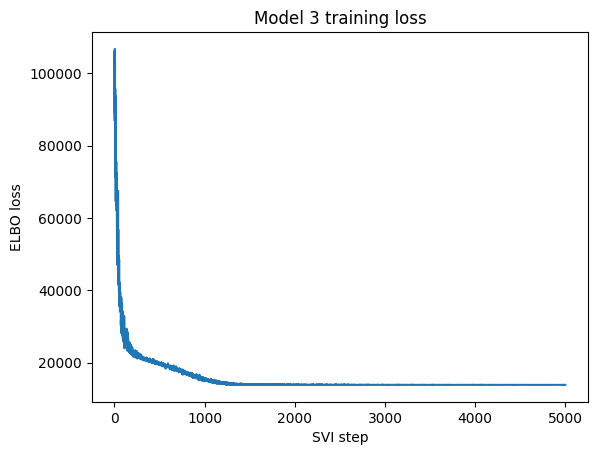

In [56]:
guide_3, losses_3 = train_svi(
    model_3_joint_frequency_monetary,
    (n_purchases, exposure, log_mean_revenue, X_tensor, country_idx, C),
    num_steps=5000,
    lr=0.01
)

plt.figure()
plt.plot(losses_3)
plt.xlabel("SVI step")
plt.ylabel("ELBO loss")
plt.title("Model 3 training loss")
plt.show()

In [61]:
predictive_3 = Predictive(
    model_3_joint_frequency_monetary,
    guide=guide_3,
    num_samples=1000,
    return_sites=[
        "alpha_lambda",
        "beta_lambda",
        "alpha_money",
        "beta_money",
        "sigma_money",
        "country_lambda",
        "country_money",
        "purchase_count_obs",
        "log_mean_revenue_obs"
    ]
)

posterior_3 = predictive_3(
    n_purchases,
    exposure,
    log_mean_revenue,
    X_tensor,
    country_idx,
    C
)

for k, v in posterior_3.items():
    print(k, v.shape)

alpha_lambda torch.Size([1000, 1])
beta_lambda torch.Size([1000, 1, 3])
alpha_money torch.Size([1000, 1])
beta_money torch.Size([1000, 1, 3])
sigma_money torch.Size([1000, 1])
country_lambda torch.Size([1000, 4])
country_money torch.Size([1000, 4])
purchase_count_obs torch.Size([1000, 4316])
log_mean_revenue_obs torch.Size([1000, 4316])


In [62]:
def summarize_vector_samples(samples, names):
    """
    Shape-safe posterior summary for vector-valued parameters.

    Expected logical shape:
        [num_samples, num_parameters]

    But Pyro Predictive may return extra singleton dimensions, such as:
        [num_samples, 1, num_parameters]

    This function reshapes safely so that the final array is:
        [num_samples_effective, num_parameters]
    """
    samples = np.asarray(samples)

    print("Original shape:", samples.shape)

    num_params = len(names)

    # Remove singleton dimensions.
    samples = np.squeeze(samples)

    print("Squeezed shape:", samples.shape)

    # Case 1: already [S, P]
    if samples.ndim == 2 and samples.shape[1] == num_params:
        samples_2d = samples

    # Case 2: [P], meaning one posterior sample only
    elif samples.ndim == 1 and samples.shape[0] == num_params:
        samples_2d = samples.reshape(1, num_params)

    # Case 3: any shape where the final dimension is the parameter dimension
    elif samples.shape[-1] == num_params:
        samples_2d = samples.reshape(-1, num_params)

    else:
        raise ValueError(
            f"Unexpected sample shape {samples.shape}. "
            f"Expected last dimension to equal number of names: {num_params}."
        )

    print("Final summary shape:", samples_2d.shape)

    rows = []
    for j, name in enumerate(names):
        s = samples_2d[:, j]
        rows.append({
            "name": name,
            "mean": s.mean(),
            "q05": np.quantile(s, 0.05),
            "q50": np.quantile(s, 0.50),
            "q95": np.quantile(s, 0.95),
        })

    return pd.DataFrame(rows)

In [63]:
beta_lambda_summary = summarize_vector_samples(
    posterior_3["beta_lambda"].detach().cpu().numpy(),
    feature_cols
)

beta_money_summary = summarize_vector_samples(
    posterior_3["beta_money"].detach().cpu().numpy(),
    feature_cols
)

print("Purchase-frequency effects")
display(beta_lambda_summary)

print("Monetary-value effects")
display(beta_money_summary)

Original shape: (1000, 1, 3)
Squeezed shape: (1000, 3)
Final summary shape: (1000, 3)
Original shape: (1000, 1, 3)
Squeezed shape: (1000, 3)
Final summary shape: (1000, 3)
Purchase-frequency effects


,name,mean,q05,q50,q95
0,recency_days,-0.761561,-0.778427,-0.761378,-0.745346
1,mean_items,0.016604,0.001615,0.016473,0.032274
2,product_diversity,-0.061852,-0.075577,-0.061831,-0.048571


Monetary-value effects


,name,mean,q05,q50,q95
0,recency_days,-0.056646,-0.068673,-0.056696,-0.044206
1,mean_items,0.361108,0.347287,0.360938,0.375151
2,product_diversity,0.179830,0.166057,0.179884,0.192552


In [66]:
def posterior_future_clv_model_3(posterior, X, country_idx, horizon_days=90):
    """
    Approximate posterior predictive CLV for each customer.

    Returns:
        clv_samples: numpy array [S, N]
    """
    X_cpu = X.detach().cpu()
    country_idx_cpu = country_idx.detach().cpu()

    N, P = X_cpu.shape
    C = int(country_idx_cpu.max().item()) + 1

    def as_scalar_samples(x):
        """
        Convert posterior scalar site to shape [S].
        """
        return x.detach().cpu().numpy().reshape(-1)

    def as_vector_samples(x, dim):
        """
        Convert posterior vector site to shape [S, dim],
        removing Pyro/Predictive singleton dimensions.
        """
        arr = x.detach().cpu().numpy()
        arr = np.squeeze(arr)

        if arr.ndim == 1:
            if arr.shape[0] == dim:
                arr = arr.reshape(1, dim)
            else:
                raise ValueError(
                    f"Expected vector dimension {dim}, but got shape {arr.shape}"
                )

        elif arr.shape[-1] == dim:
            arr = arr.reshape(-1, dim)

        else:
            raise ValueError(
                f"Expected last dimension {dim}, but got shape {arr.shape}"
            )

        return torch.tensor(arr, dtype=torch.float32)

    alpha_lambda = torch.tensor(
        as_scalar_samples(posterior["alpha_lambda"]),
        dtype=torch.float32
    )

    alpha_money = torch.tensor(
        as_scalar_samples(posterior["alpha_money"]),
        dtype=torch.float32
    )

    sigma_money = torch.tensor(
        as_scalar_samples(posterior["sigma_money"]),
        dtype=torch.float32
    )

    beta_lambda = as_vector_samples(posterior["beta_lambda"], P)
    beta_money = as_vector_samples(posterior["beta_money"], P)

    country_lambda = as_vector_samples(posterior["country_lambda"], C)
    country_money = as_vector_samples(posterior["country_money"], C)

    S = min(
        alpha_lambda.shape[0],
        beta_lambda.shape[0],
        alpha_money.shape[0],
        beta_money.shape[0],
        sigma_money.shape[0],
        country_lambda.shape[0],
        country_money.shape[0],
    )

    horizon_years = horizon_days / 365.25
    clv_samples = []

    for s in range(S):
        beta_lambda_s = beta_lambda[s].reshape(P)
        beta_money_s = beta_money[s].reshape(P)

        country_lambda_s = country_lambda[s].reshape(C)
        country_money_s = country_money[s].reshape(C)

        alpha_lambda_s = alpha_lambda[s].reshape(())
        alpha_money_s = alpha_money[s].reshape(())
        sigma_money_s = sigma_money[s].reshape(())

        log_rate = (
            alpha_lambda_s
            + torch.matmul(X_cpu, beta_lambda_s)
            + country_lambda_s[country_idx_cpu]
        )

        rate = torch.exp(log_rate)

        money_mean = (
            alpha_money_s
            + torch.matmul(X_cpu, beta_money_s)
            + country_money_s[country_idx_cpu]
        )

        future_counts = dist.Poisson(rate * horizon_years).sample()
        future_avg_revenue = dist.LogNormal(money_mean, sigma_money_s).sample()

        clv = future_counts * future_avg_revenue
        clv_samples.append(clv.numpy())

    return np.stack(clv_samples, axis=0)

In [67]:
clv_90 = posterior_future_clv_model_3(
    posterior_3,
    X_tensor,
    country_idx,
    horizon_days=90
)

clv_summary = customer_df[["CustomerID", "CountryGroup", "n_purchases", "total_revenue", "recency_days"]].copy()

clv_summary["clv_90_mean"] = clv_90.mean(axis=0)
clv_summary["clv_90_q05"] = np.quantile(clv_90, 0.05, axis=0)
clv_summary["clv_90_q50"] = np.quantile(clv_90, 0.50, axis=0)
clv_summary["clv_90_q95"] = np.quantile(clv_90, 0.95, axis=0)

clv_summary.sort_values("clv_90_mean", ascending=False).head(20)

,CustomerID,CountryGroup,n_purchases,total_revenue,recency_days,clv_90_mean,clv_90_q05,clv_90_q50,clv_90_q95
4314,18251,United Kingdom,1,4314.72,86,1.896397e+07,0.00000,1.350774e+07,5.585804e+07
10,12357,Other,1,6207.67,32,5.564069e+04,0.00000,3.847866e+04,1.781775e+05
278,12688,Other,1,4873.81,113,5.514217e+04,0.00000,2.100118e+04,2.059957e+05
597,13135,United Kingdom,1,3096.00,196,4.851359e+04,0.00000,3.421418e+04,1.756185e+05
27,12378,Other,1,4008.62,129,3.609516e+04,0.00000,0.000000e+00,1.437651e+05
3693,17404,Other,15,31906.82,3,1.583256e+04,0.00000,1.199151e+04,4.259841e+04
2221,15372,United Kingdom,1,2007.40,136,1.440819e+04,0.00000,1.035719e+04,4.418061e+04
519,13027,United Kingdom,6,6912.00,113,1.351133e+04,0.00000,9.994293e+03,4.257195e+04
3230,16754,United Kingdom,1,2002.40,371,1.176167e+04,0.00000,0.000000e+00,6.805612e+04
329,12752,Other,1,4366.78,80,1.154309e+04,0.00000,8.010357e+03,3.685862e+04


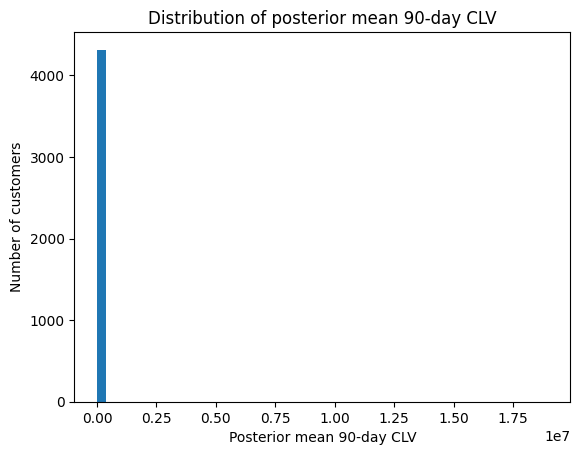

In [76]:
plt.figure()
plt.hist(clv_summary["clv_90_mean"], bins=50)
plt.xlabel("Posterior mean 90-day CLV")
plt.ylabel("Number of customers")
plt.title("Distribution of posterior mean 90-day CLV")
plt.show()

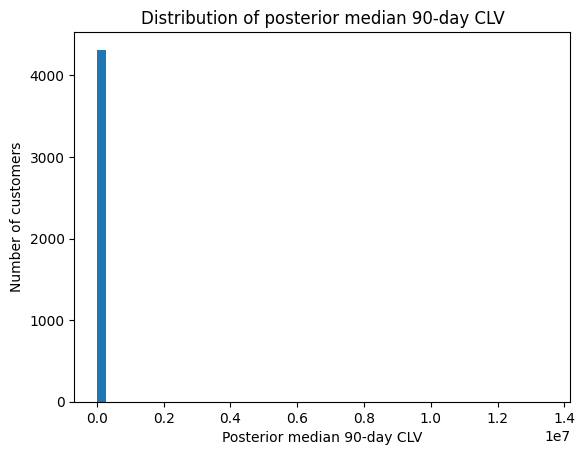

In [77]:
clv_summary["clv_90_median"] = np.quantile(clv_90, 0.50, axis=0)

plt.figure()
plt.hist(clv_summary["clv_90_median"], bins=50)
plt.xlabel("Posterior median 90-day CLV")
plt.ylabel("Number of customers")
plt.title("Distribution of posterior median 90-day CLV")
plt.show()

In [71]:
clv_summary["clv_90_mean"].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.995, 0.999])

count    4.316000e+03
mean     5.083125e+03
std      2.886555e+05
min      2.352488e+01
50%      5.964532e+02
90%      1.051554e+03
95%      1.331154e+03
99%      2.890491e+03
99.5%    5.824265e+03
99.9%    2.971244e+04
max      1.896397e+07
Name: clv_90_mean, dtype: float64

In [73]:
clv_summary.sort_values("clv_90_mean", ascending=False).head(20)

,CustomerID,CountryGroup,n_purchases,total_revenue,recency_days,clv_90_mean,clv_90_q05,clv_90_q50,clv_90_q95
4314,18251,United Kingdom,1,4314.72,86,1.896397e+07,0.00000,1.350774e+07,5.585804e+07
10,12357,Other,1,6207.67,32,5.564069e+04,0.00000,3.847866e+04,1.781775e+05
278,12688,Other,1,4873.81,113,5.514217e+04,0.00000,2.100118e+04,2.059957e+05
597,13135,United Kingdom,1,3096.00,196,4.851359e+04,0.00000,3.421418e+04,1.756185e+05
27,12378,Other,1,4008.62,129,3.609516e+04,0.00000,0.000000e+00,1.437651e+05
3693,17404,Other,15,31906.82,3,1.583256e+04,0.00000,1.199151e+04,4.259841e+04
2221,15372,United Kingdom,1,2007.40,136,1.440819e+04,0.00000,1.035719e+04,4.418061e+04
519,13027,United Kingdom,6,6912.00,113,1.351133e+04,0.00000,9.994293e+03,4.257195e+04
3230,16754,United Kingdom,1,2002.40,371,1.176167e+04,0.00000,0.000000e+00,6.805612e+04
329,12752,Other,1,4366.78,80,1.154309e+04,0.00000,8.010357e+03,3.685862e+04


In [74]:
customer_df.sort_values("mean_revenue", ascending=False)[
    ["CustomerID", "CountryGroup", "n_purchases", "mean_revenue", "total_revenue", "recency_days"]
].head(20)

,CustomerID,CountryGroup,n_purchases,mean_revenue,total_revenue,recency_days
2011,15098,United Kingdom,3,13305.500000,39916.50,181
10,12357,Other,1,6207.670000,6207.67,32
196,12590,Germany,2,4932.130000,9864.26,210
278,12688,Other,1,4873.810000,4873.81,113
329,12752,Other,1,4366.780000,4366.78,80
4314,18251,United Kingdom,1,4314.720000,4314.72,86
152,12536,France,3,4200.610000,12601.83,42
2678,16000,United Kingdom,3,4131.233333,12393.70,2
27,12378,Other,1,4008.620000,4008.62,129
73,12435,Other,2,3914.945000,7829.89,79


In [69]:
baseline = customer_df.copy()

# Simple deterministic score:
# High frequency, high monetary value, low recency.
baseline["rfm_score"] = (
    np.log1p(baseline["n_purchases"])
    + np.log1p(baseline["mean_revenue"])
    - np.log1p(baseline["recency_days"])
)

baseline[["CustomerID", "CountryGroup", "n_purchases", "mean_revenue", "recency_days", "rfm_score"]] \
    .sort_values("rfm_score", ascending=False) \
    .head(20)

,CustomerID,CountryGroup,n_purchases,mean_revenue,recency_days,rfm_score
1069,13798,United Kingdom,57,651.821930,0,10.541747
326,12748,United Kingdom,209,161.338421,0,10.436791
3683,17389,United Kingdom,34,936.284706,0,10.398335
570,13098,United Kingdom,28,1031.515714,0,10.307049
1058,13777,United Kingdom,33,787.186667,0,10.196095
3894,17675,United Kingdom,31,657.234839,0,9.955298
4010,17841,United Kingdom,124,330.577177,1,9.939027
3712,17428,United Kingdom,28,616.316071,0,9.792677
2083,15189,United Kingdom,41,395.741220,0,9.720954
1257,14051,United Kingdom,23,678.712609,0,9.699724


In [78]:
comparison = clv_summary.merge(
    baseline[["CustomerID", "rfm_score"]],
    on="CustomerID",
    how="left"
)

comparison[["clv_90_median", "rfm_score"]].corr()

,clv_90_median,rfm_score
clv_90_median,1.000000,0.011633
rfm_score,0.011633,1.000000
